# Function Transformer

## Import of libs

In [3]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [4]:
df=pd.read_csv("Titanic-Dataset.csv",usecols=["Age","Fare","Survived"])
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [6]:
df["Age"] = df["Age"].fillna(df["Age"].mean())


In [7]:
x_train,x_test,y_train,y_test=train_test_split(df.iloc[:,1:],df.iloc[:,0],test_size=0.2,random_state=40)

In [8]:
x_train,x_test,y_train,y_test

(      Age      Fare
 661  40.0    7.2250
 393  23.0  113.2750
 266  16.0   39.6875
 144  18.0   11.5000
 446  13.0   19.5000
 ..    ...       ...
 440  45.0   26.2500
 165   9.0   20.5250
 7     2.0   21.0750
 219  30.0   10.5000
 326  61.0    6.2375
 
 [712 rows x 2 columns],
            Age     Fare
 246  25.000000   7.7750
 588  22.000000   8.0500
 472  33.000000  27.7500
 71   16.000000  46.9000
 654  18.000000   6.7500
 ..         ...      ...
 284  29.699118  26.0000
 727  29.699118   7.7375
 599  49.000000  56.9292
 525  40.500000   7.7500
 457  29.699118  51.8625
 
 [179 rows x 2 columns],
 661    0
 393    1
 266    0
 144    0
 446    1
       ..
 440    1
 165    1
 7      0
 219    0
 326    0
 Name: Survived, Length: 712, dtype: int64,
 246    0
 588    0
 472    1
 71     0
 654    0
       ..
 284    0
 727    1
 599    1
 525    0
 457    1
 Name: Survived, Length: 179, dtype: int64)

In [9]:
# use of displot or histogram/qq plot to find the normal distribution

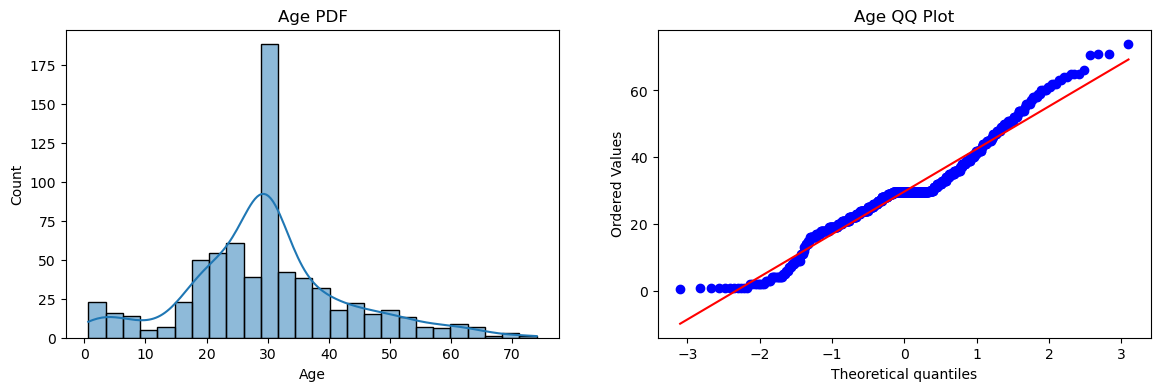

In [10]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
sns.histplot(x_train['Age'], kde=True)
plt.title('Age PDF')

plt.subplot(1,2,2)
stats.probplot(x_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [11]:
#creating 2 models of logisticRegression and DecisionTreeClassifier
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(x_train, y_train)
clf2.fit(x_train, y_train)

y_pred = clf.predict(x_test)
y_pred1 = clf2.predict(x_test)

print("Accuracy logisticRegression", accuracy_score(y_test, y_pred))
print("Accuracy DecisionTreeClassifier", accuracy_score(y_test, y_pred1))


Accuracy logisticRegression 0.6536312849162011
Accuracy DecisionTreeClassifier 0.6424581005586593


In [12]:
#using log transformer

trf = FunctionTransformer(func=np.log1p)

X_train_transformed = trf.fit_transform(x_train)
X_test_transformed = trf.transform(x_test)


In [13]:

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred = clf.predict(x_test)
y_pred1 = clf2.predict(x_test)

print("Accuracy logisticRegression", accuracy_score(y_test, y_pred))
print("Accuracy DecisionTreeClassifier", accuracy_score(y_test, y_pred1))

Accuracy logisticRegression 0.6536312849162011
Accuracy DecisionTreeClassifier 0.5921787709497207


In [14]:
#Training of transformed data
X_transformed = trf.fit_transform(x_test)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("Accuracy logisticRegression", np.mean(cross_val_score(clf,X_transformed,y_test,scoring='accuracy',cv=10)))
print("Accuracy DecisionTreeClassifier", np.mean(cross_val_score(clf2,X_transformed,y_test,scoring='accuracy',cv=10)))

Accuracy logisticRegression 0.6983660130718954
Accuracy DecisionTreeClassifier 0.6032679738562091


Text(0.5, 1.0, 'Age After Log')

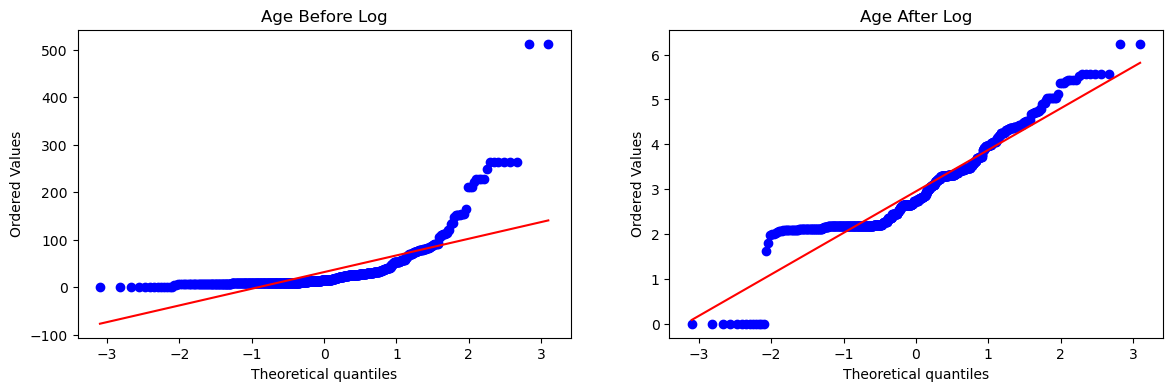

In [15]:
#data after an before the Log Transformetion
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['Fare'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Age After Log')


In [16]:
# Applying the transformation on the fare column only 

trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(x_train)
X_test_transformed2 = trf2.transform(x_test)

In [17]:
#model training
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT", accuracy_score(y_test,y_pred2))


Accuracy LR 0.6759776536312849
Accuracy DT 0.6536312849162011


In [23]:
#in the parameter the function we will pass will be applied in the fare column of the dataset and will show the graph

def apply_transform(transform):
    x = df.iloc[:, 1:3]
    y = df.iloc[:, 0]

    trf = ColumnTransformer([('log', FunctionTransformer(transform), ['Fare'])], remainder='passthrough')

    x_trans = trf.fit_transform(x)

    clf = LogisticRegression()

    print("Accuracy", np.mean(cross_val_score(clf, x_trans, y, scoring='accuracy', cv=10)))

    plt.figure(figsize=(14, 4))

    plt.subplot(121)
    stats.probplot(x['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(x_trans[:, 0], dist="norm", plot=plt)
    plt.title('Fare After Transform')


Accuracy 0.6589013732833957


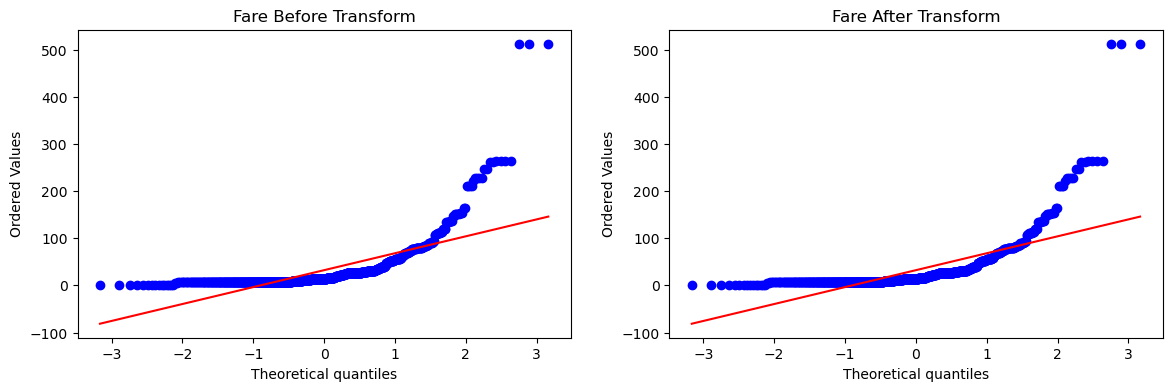

In [32]:
#Initial data
apply_transform(lambda x:x)

Accuracy 0.6611485642946316


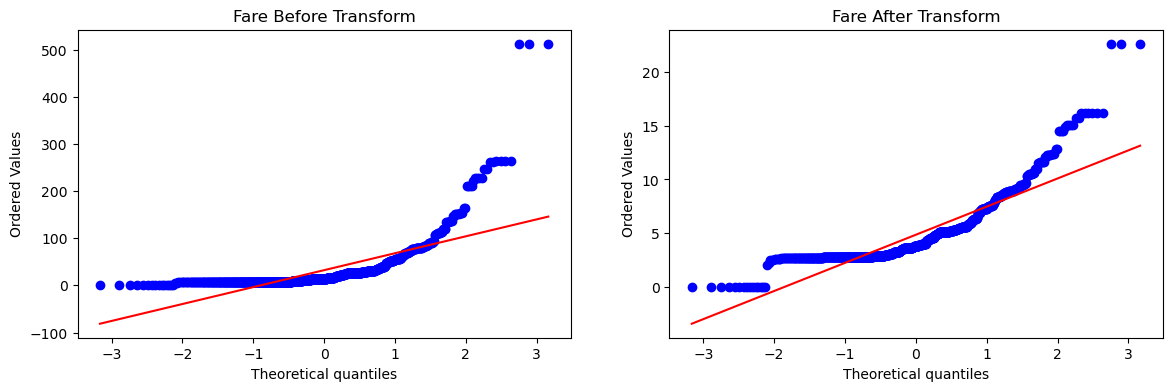

In [33]:
#after appling the function
apply_transform(lambda x:x**0.5)